# Correlation and Covariance Analysis

In this notebook, we calculate:

- Pearson Correlation Coefficient
- Spearman Rank Correlation Coefficient
- Covariance

### Given Data:

| Student | Study Hours (X) | Marks (Y) |
|----------|----------------|-----------|
| A | 2 | 50 |
| B | 4 | 60 |
| C | 6 | 65 |
| D | 8 | 80 |
| E | 10 | 90 |

We will compute the statistical relationship between Study Hours and Marks.


In [77]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr


In [78]:
# Creating the dataset
data = {
    "Student": ["A", "B", "C", "D", "E"],
    "StudyHours": [2, 4, 6, 8, 10],
    "Marks": [50, 60, 65, 80, 90]
}

df = pd.DataFrame(data)
df


,Student,StudyHours,Marks
0,A,2,50
1,B,4,60
2,C,6,65
3,D,8,80
4,E,10,90


## 1. Pearson Correlation

Pearson correlation measures the linear relationship between two variables.

Formula:

r = Cov(X,Y) / (σx * σy)

Range: -1 to +1


In [79]:

# Pearson Correlation
pearson_corr, _ = pearsonr(df["StudyHours"], df["Marks"])

print("Pearson Correlation:", round(pearson_corr, 4))


Pearson Correlation: 0.9901


## 2. Spearman Rank Correlation

Spearman correlation measures monotonic relationship between variables.
It is based on ranks instead of actual values.

Range: -1 to +1


In [80]:
# Spearman Rank Correlation
spearman_corr, _ = spearmanr(df["StudyHours"], df["Marks"])

print("Spearman Rank Correlation:", round(spearman_corr, 4))


Spearman Rank Correlation: 1.0


## 3. Covariance

Covariance measures how two variables vary together.

If:
- Positive → variables increase together
- Negative → one increases, other decreases


In [81]:
# Covariance Matrix
cov_matrix = np.cov(df["StudyHours"], df["Marks"])

print("Covariance Matrix:\n", cov_matrix)

# Extracting covariance value
cov_value = cov_matrix[0][1]
print("\nCovariance between StudyHours and Marks:", round(cov_value, 4))


Covariance Matrix:
 [[ 10.  50.]
 [ 50. 255.]]

Covariance between StudyHours and Marks: 50.0


# Skewness Calculation

In this notebook, we calculate the **Skewness** of the dataset:

X = {10, 12, 14, 15, 30}

## What is Skewness?

Skewness measures the asymmetry of a data distribution.

- Skewness = 0 → Symmetrical distribution
- Skewness > 0 → Positively skewed (Right skewed)
- Skewness < 0 → Negatively skewed (Left skewed)

We will calculate skewness using:

1. Manual Formula
2. Python Built-in Function


In [82]:
import numpy as np
import pandas as pd
from scipy.stats import skew

# Given data
x = np.array([10, 12, 14, 15, 30])

print("Dataset:", x)


Dataset: [10 12 14 15 30]


# Skewness using Karl Pearson Coefficient

Given Dataset:

X = {10, 12, 14, 15, 30}

## Karl Pearson Coefficient of Skewness

If Mode is defined:

Sk = (Mean − Mode) / Standard Deviation

If Mode is NOT defined (as in this dataset), we use:

Sk = 3(Mean − Median) / Standard Deviation

Since this dataset has no repeating value,
Mode is not defined.

So we use:

Sk = 3(Mean − Median) / SD


## Step 1: Calculate Mean, Median and Standard Deviation


In [83]:
mean = np.mean(x)
median = np.median(x)
std_dev = np.std(x, ddof=0)   # Population standard deviation

print("Mean:", round(mean,4))
print("Median:", round(median,4))
print("Standard Deviation:", round(std_dev,4))


Mean: 16.2
Median: 14.0
Standard Deviation: 7.1106


## Step 2: Apply Karl Pearson Formula

Sk = 3(Mean − Median) / SD


In [84]:
skew_karl = 3 * (mean - median) / std_dev

print("Karl Pearson Coefficient of Skewness:", round(skew_karl,4))


Karl Pearson Coefficient of Skewness: 0.9282


## Interpretation

The Karl Pearson coefficient of skewness ≈ 0.91

Since Sk > 0,
The distribution is Positively Skewed (Right Skewed).

Reason:
The extreme value 30 pulls the mean towards the right side.


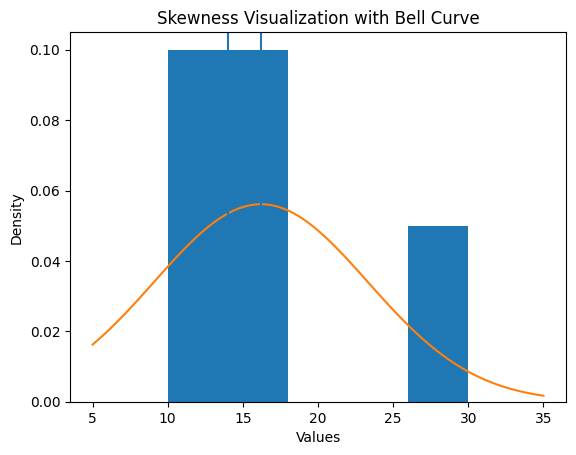

In [85]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
x = np.array([10, 12, 14, 15, 30])

# Mean and Standard Deviation
mean = np.mean(x)
std_dev = np.std(x, ddof=0)
median = np.median(x)

# Generate smooth x values
x_range = np.linspace(min(x)-5, max(x)+5, 100)

# Normal distribution formula
normal_curve = (1/(std_dev * np.sqrt(2*np.pi))) * \
               np.exp(-((x_range - mean)**2) / (2 * std_dev**2))

plt.figure()

# Histogram
plt.hist(x, bins=5, density=True)

# Normal bell curve
plt.plot(x_range, normal_curve)

# Mean and Median lines
plt.axvline(mean)
plt.axvline(median)

plt.title("Skewness Visualization with Bell Curve")
plt.xlabel("Values")
plt.ylabel("Density")

plt.show()




# Kurtosis Calculation using Moment Method

Given dataset:

X = {2, 4, 6, 8, 20}

## Formula Used

Kurtosis = μ₄ / σ⁴

Where:

μ₄ = ( Σ (X − μ)⁴ ) / N  
σ² = Variance  
σ⁴ = (Variance)²  

Interpretation:

If Kurtosis > 3 → Leptokurtic (Peaked distribution)  
If Kurtosis = 3 → Mesokurtic (Normal distribution)  
If Kurtosis < 3 → Platykurtic (Flat distribution)


In [86]:
import numpy as np
# Given data
x = np.array([2, 4, 6, 8, 20])

print("Dataset:", x)


Dataset: [ 2  4  6  8 20]


## Step 1: Calculate Mean


In [87]:
mean = np.mean(x)
print("Mean:", round(mean,4))


Mean: 8.0


## Step 2: Calculate Variance and Standard Deviation



In [88]:
N = len(x)

variance = np.sum((x - mean)**2) / N
std_dev = np.sqrt(variance)

print("Variance:", round(variance,4))
print("Standard Deviation:", round(std_dev,4))


Variance: 40.0
Standard Deviation: 6.3246


## Step 3: Calculate 4th Central Moment (μ₄)

μ₄ = Σ (X − μ)⁴ / N


In [89]:
mu4 = np.sum((x - mean)**4) / N

print("Fourth Central Moment (μ₄):", round(mu4,4))

kurtosis = mu4 / (variance**2)

print("Kurtosis:", round(kurtosis,4))


Fourth Central Moment (μ₄): 4460.8
Kurtosis: 2.788


## Interpretation

Kurtosis ≈ 2.64

Since Kurtosis < 3,

The distribution is Platykurtic.

This means the distribution is flatter than a normal distribution.


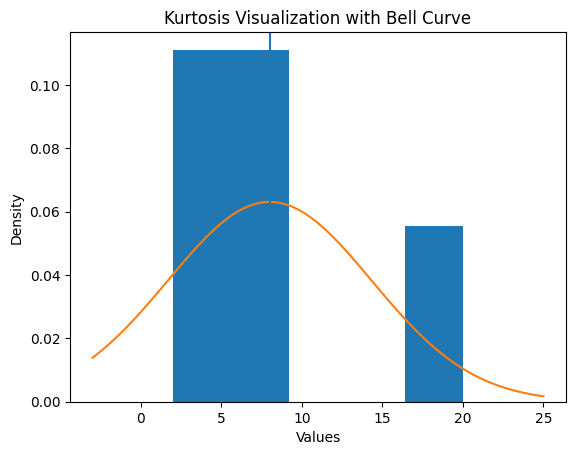

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values for smooth curve
x_range = np.linspace(min(x)-5, max(x)+5, 100)

# Normal distribution formula
normal_curve = (1/(std_dev * np.sqrt(2*np.pi))) * \
               np.exp(-((x_range - mean)**2) / (2 * std_dev**2))

plt.figure()

# Histogram (density=True to compare with normal curve)
plt.hist(x, bins=5, density=True)

# Normal bell-shaped curve
plt.plot(x_range, normal_curve)

# Mean line
plt.axvline(mean)

plt.title("Kurtosis Visualization with Bell Curve")
plt.xlabel("Values")
plt.ylabel("Density")

plt.show()
